# Trading with a set, low Speed Strategy (varied competitor speeds (even spread), or many competitors trade at highest speeds)

## Assumes trade at minimal speed, to guarantee a certain pnl for round2 manual trading

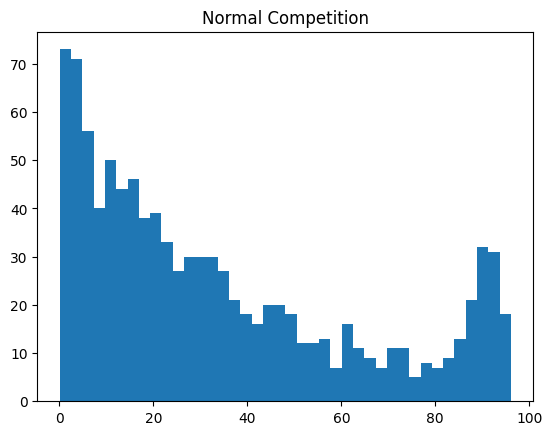

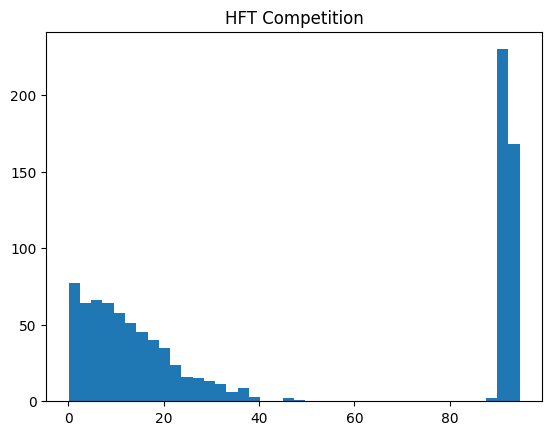

Normal Best: (23, 77, 0) 24232.991676237143
HFT Best: (23, 77, 0) 24232.991676237143


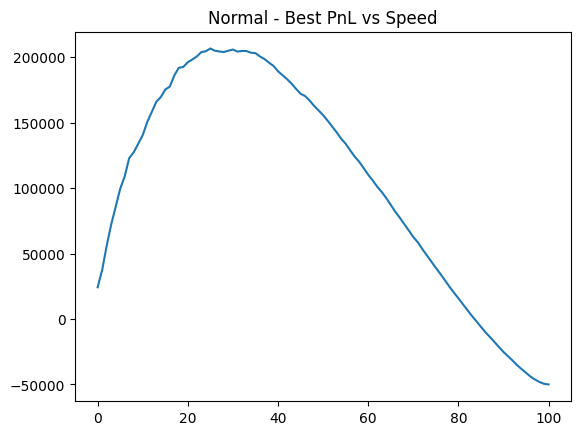

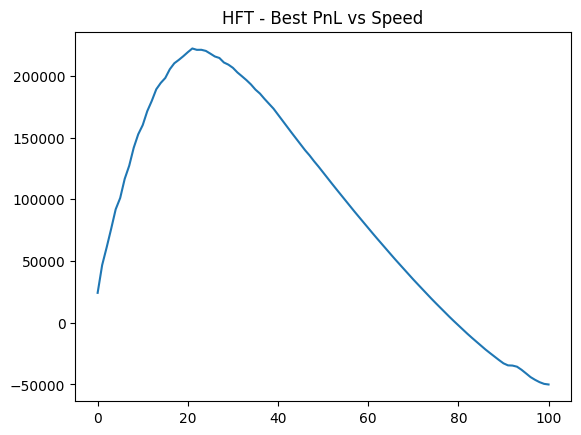

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ========================
# CONFIG
# ========================
BUDGET = 50000
STEP = 1

# ========================
# PILLAR FUNCTIONS
# ========================
def research(x):
    return 200_000 * np.log(1 + x) / np.log(101)

def scale(x):
    return 7 * x / 100

# ========================
# COMPETITION GENERATION
# ========================
def generate_competition(n=1000, seed=42):
    np.random.seed(seed)
    
    n_low = int(0.6 * n)
    n_mid = int(0.3 * n)
    n_top = n - n_low - n_mid
    
    low = np.random.beta(1, 5, size=n_low) * 100
    mid = np.random.beta(2, 2, size=n_mid) * 100
    top = np.random.normal(loc=90, scale=3, size=n_top)
    top = np.clip(top, 70, 100)
    
    return np.concatenate([low, mid, top])

def generate_competition_hft(n=1000, seed=43):
    np.random.seed(seed)
    
    n_top = int(0.4 * n)
    n_rest = n - n_top
    
    rest = np.random.beta(1, 4, size=n_rest) * 60
    top = np.random.normal(loc=92, scale=0.8, size=n_top)
    top = np.clip(top, 85, 100)
    
    return np.concatenate([rest, top])

def preprocess_competition(others):
    return np.sort(others)

# ========================
# RANK SPEED
# ========================
def rank_speed_fast(my_sp, sorted_others):
    idx = np.searchsorted(sorted_others, my_sp, side='right')
    rank = len(sorted_others) - idx + 1
    n = len(sorted_others) + 1
    return 0.9 - (rank - 1) * (0.8 / (n - 1))

# ========================
# PnL
# ========================
def pnl(r, s, sp, sorted_others):
    if r + s + sp > 100:
        return -1e18
    
    R = research(r)
    S = scale(s)
    V = rank_speed_fast(sp, sorted_others)
    cost = BUDGET * (r + s + sp) / 100
    
    return R * S * V - cost

# ========================
# RUN
# ========================
others = generate_competition(1000, seed=42)
others_hft = generate_competition_hft(1000, seed=43)

sorted_others = preprocess_competition(others)
sorted_others_hft = preprocess_competition(others_hft)

# ========================
# HISTOGRAMS
# ========================
plt.hist(others, bins=40)
plt.title("Normal Competition")
plt.show()

plt.hist(others_hft, bins=40)
plt.title("HFT Competition")
plt.show()

# ========================
# GRID SEARCH
# ========================
best_val = -1e18
best_alloc = None

hft_best_val = -1e18
hft_best_alloc = None
SET_SPEED = 0

for r in range(0, 101, STEP):
    for s in range(0, 101 - r, STEP):            
        val = pnl(r, s, SET_SPEED, sorted_others)
        hft_val = pnl(r, s, SET_SPEED, sorted_others_hft)

        if val > best_val:
            best_val = val
            best_alloc = (r, s, SET_SPEED)

        if hft_val > hft_best_val:
            hft_best_val = hft_val
            hft_best_alloc = (r, s, SET_SPEED)

print("Normal Best:", best_alloc, best_val)
print("HFT Best:", hft_best_alloc, hft_best_val)

# ========================
# PLOTS
# ========================
def plot_analysis(title, sorted_others, best_alloc):
    sp_vals = list(range(101))

    # Best PnL vs Speed
    best_pnl_by_sp = []
    for sp in sp_vals:
        best_local = -1e18
        for r in range(0, 101, STEP):
            for s in range(0, 101 - r, STEP):
                val = pnl(r, s, sp, sorted_others)
                if val > best_local:
                    best_local = val
        best_pnl_by_sp.append(best_local)

    plt.plot(sp_vals, best_pnl_by_sp)
    plt.title(f"{title} - Best PnL vs Speed")
    plt.show()

# run both scenarios
plot_analysis("Normal", sorted_others, best_alloc)
plot_analysis("HFT", sorted_others_hft, hft_best_alloc)